# DENOISING AUTOENCODER (Tutorial 7)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
# Load MNIST dataset
# We only need the images (x), not the labels (_) because autoencoders are unsupervised
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values from [0, 255] to [0.0, 1.0]
# Neural networks train better with small float values
x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

# Reshape: add channel dimension (1 = grayscale)
# Keras Conv2D expects shape: (samples, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


In [3]:
# Add Gaussian noise to images
# noise_factor controls how strong the noise is (0.5 = moderate noise)
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy  = x_test  + noise_factor * np.random.normal(size=x_test.shape)

# Clip values to keep them in valid pixel range [0, 1]
# Adding noise can push values outside this range
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy  = np.clip(x_test_noisy,  0., 1.)

print("Noisy data range:", x_train_noisy.min(), "to", x_train_noisy.max())

Noisy data range: 0.0 to 1.0


In [4]:
# --- ENCODER ---
# Takes the noisy 28x28 image and compresses it into a smaller representation

input_img = Input(shape=(28, 28, 1))  # Input layer: 28x28 grayscale image

# First conv block: 32 filters, 3x3 kernel, relu activation, same padding
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)  # Output: 28x28x32
x = MaxPooling2D((2, 2), padding='same')(x)                            # Output: 14x14x32

# Second conv block: 64 filters — more filters to capture more complex features
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)          # Output: 14x14x64
encoded = MaxPooling2D((2, 2), padding='same')(x)                      # Output: 7x7x64 (bottleneck!)

print("Encoded (bottleneck) shape: 7x7x64 =", 7*7*64, "values (compressed from", 28*28, "pixels)")

Encoded (bottleneck) shape: 7x7x64 = 3136 values (compressed from 784 pixels)


In [5]:
# --- DECODER ---
# Takes the compressed 7x7x64 representation and reconstructs the 28x28 clean image

x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)   # Output: 7x7x64
x = UpSampling2D((2, 2))(x)                                          # Output: 14x14x64 (reverse of MaxPooling)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)         # Output: 14x14x32
x = UpSampling2D((2, 2))(x)                                          # Output: 28x28x32

# Final layer: 1 filter → 1 channel (grayscale), sigmoid to keep values in [0,1]
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x) # Output: 28x28x1

print("Output shape: 28x28x1 — same as input!")

Output shape: 28x28x1 — same as input!


In [6]:
# Build and compile the autoencoder model
# Input: noisy image | Output: clean reconstructed image
autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer=Adam(),              # Adam: adaptive learning rate optimizer
    loss='binary_crossentropy'     # Good for pixel values in [0,1] range
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the autoencoder
# Input: noisy images | Target: original clean images
# The model learns to remove noise!
history = autoencoder.fit(
    x_train_noisy, x_train,          # noisy input → clean target
    epochs=5,
    batch_size=128,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 181s 381ms/step - loss: 0.1539 - val_loss: 0.1107
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 175s 374ms/step - loss: 0.1083 - val_loss: 0.1041
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 176s 374ms/step - loss: 0.1037 - val_loss: 0.1012
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 384ms/step - loss: 0.1014 - val_loss: 0.0994
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 196s 372ms/step - loss: 0.0999 - val_loss: 0.0983


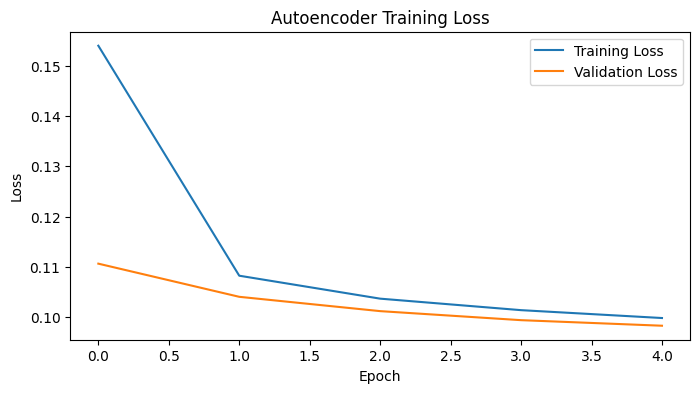

In [8]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


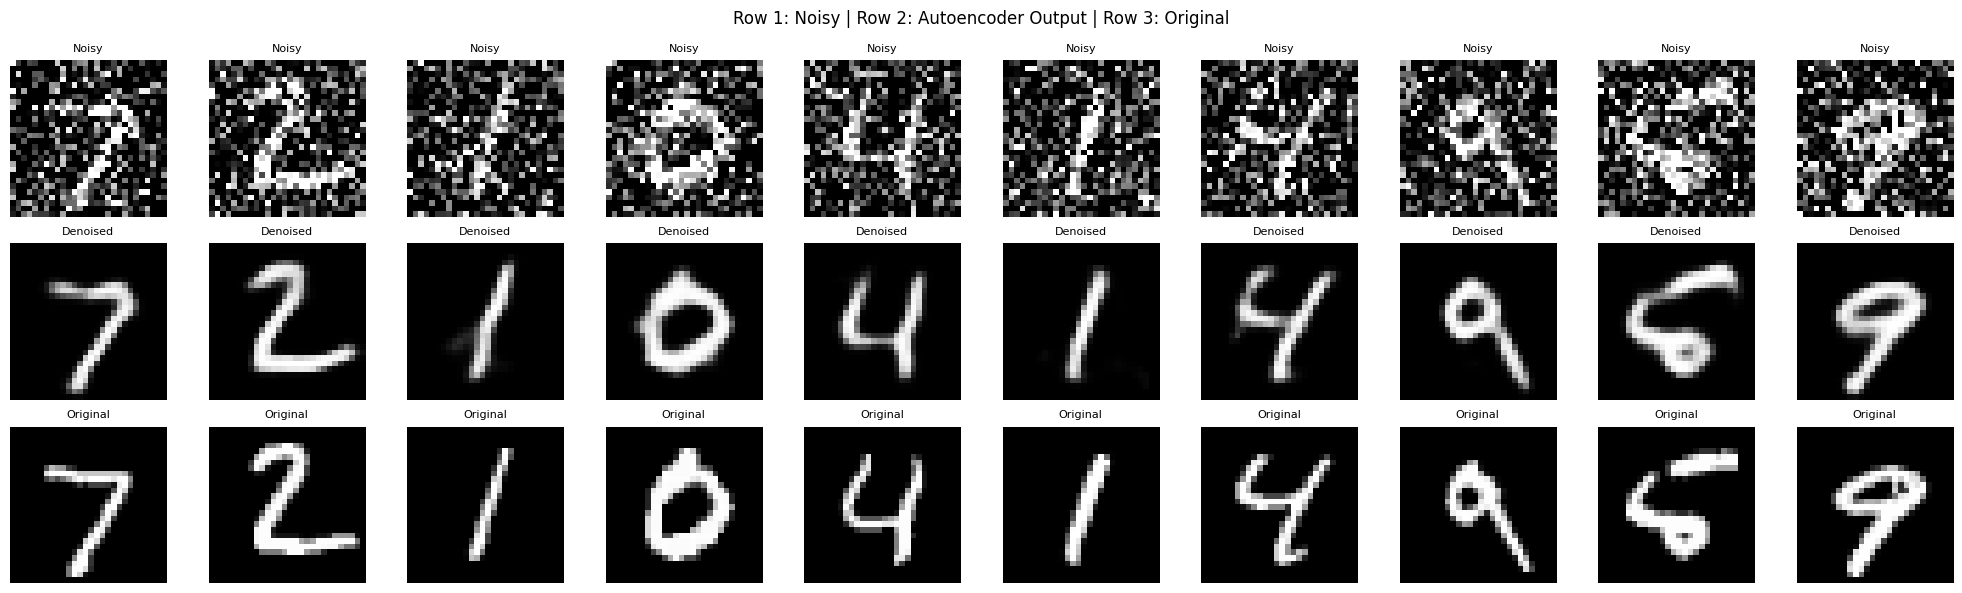

In [9]:
# Run denoising on test images
decoded_imgs = autoencoder.predict(x_test_noisy[:10])

# Visualize: Row 1 = Noisy input | Row 2 = Denoised output | Row 3 = Original
plt.figure(figsize=(20, 6))
for i in range(10):
    # Noisy input
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title('Noisy', fontsize=8)
    plt.axis('off')

    # Denoised output
    ax = plt.subplot(3, 10, i + 11)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title('Denoised', fontsize=8)
    plt.axis('off')

    # Original clean image
    ax = plt.subplot(3, 10, i + 21)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title('Original', fontsize=8)
    plt.axis('off')

plt.suptitle('Row 1: Noisy | Row 2: Autoencoder Output | Row 3: Original', fontsize=12)
plt.tight_layout()
plt.show()